In [2]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.multioutput import MultiOutputClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.inspection import permutation_importance
import os
import fs
import process_data as dp
import mdp_utils
from scipy import stats
import matplotlib.pyplot as plt
np.random.seed(66)  

%load_ext autoreload
%autoreload 2

Failed to read module file 'C:\Python311\Lib\re\_casefix.py' for module 're._casefix': UnicodeDecodeError
Traceback (most recent call last):
  File "c:\Users\shirl\Documents\Studie\2025-2026\Thesis\personalized-coping-challenges\.venv\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\shirl\Documents\Studie\2025-2026\Thesis\personalized-coping-challenges\.venv\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Python311\Lib\importlib\__init__.py", line 126, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1206, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1178, in _find_and_load
  File "<frozen importl

In [11]:
data_folder = 'C:\\Users\\shirl\\Documents\\Studie\\2025-2026\\Thesis\\personalized-coping-challenges\\data'
results_folder = 'C:\\Users\\shirl\\Documents\\Studie\\2025-2026\\Thesis\\personalized-coping-challenges\\results\\'

num_clusters = 3
num_actions = num_clusters * 2
max_count = 0

# Load data
action_data = pd.read_csv(os.path.join(data_folder, 'challenge_info.csv'))
samples = pd.read_csv(os.path.join(data_folder, 'processed_samples_adjusted_full_optimistic.csv'))

cluster_vars = ['likedness', 'usefulness', 'difficulty']
actions_clustered, _, cluster_cols = dp.cluster_actions(action_data, cluster_vars, num_clusters=num_clusters)

cluster_col = 'cluster_all'
action_col = 'joint_cluster'

reward_cols = ["r_likedness", "r_usefulness", "r_expert", "r_diversity", "r_return"]
weights = [1/len(reward_cols)] * len(reward_cols)  # Equal weights for all objectives

### The features we want to choose from

In [12]:
possible_state_features = ['TIR', 'TIME_Q', 'GOOD', 'MOT']

### Check best binning method
We want to find as equal sized bins as possible

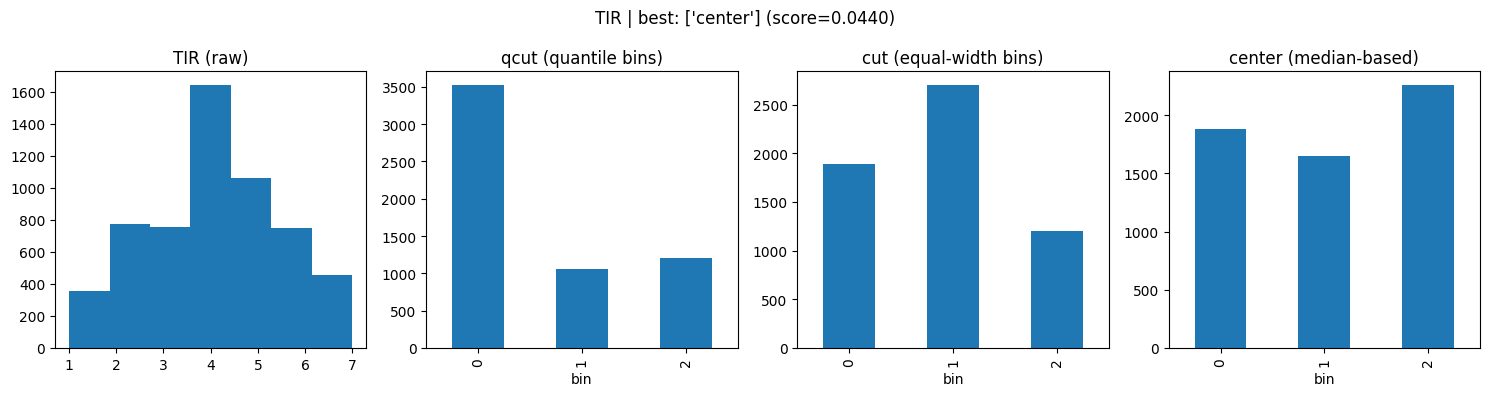

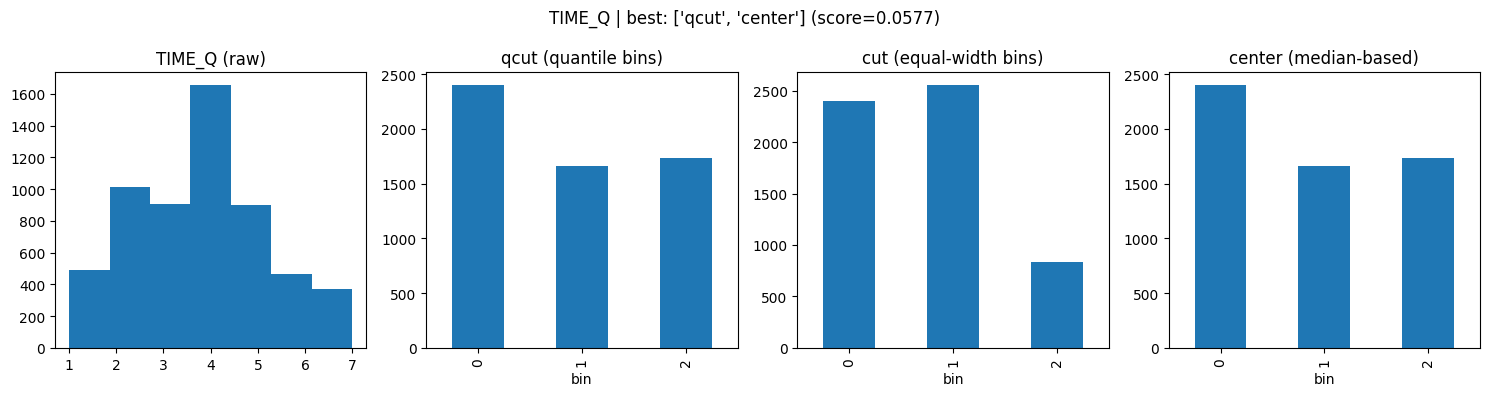

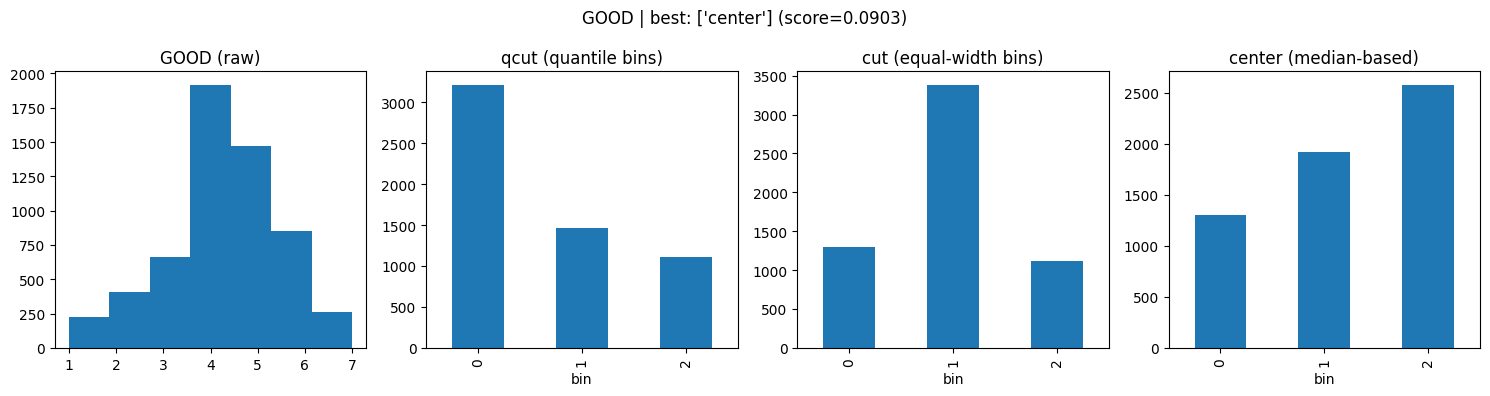

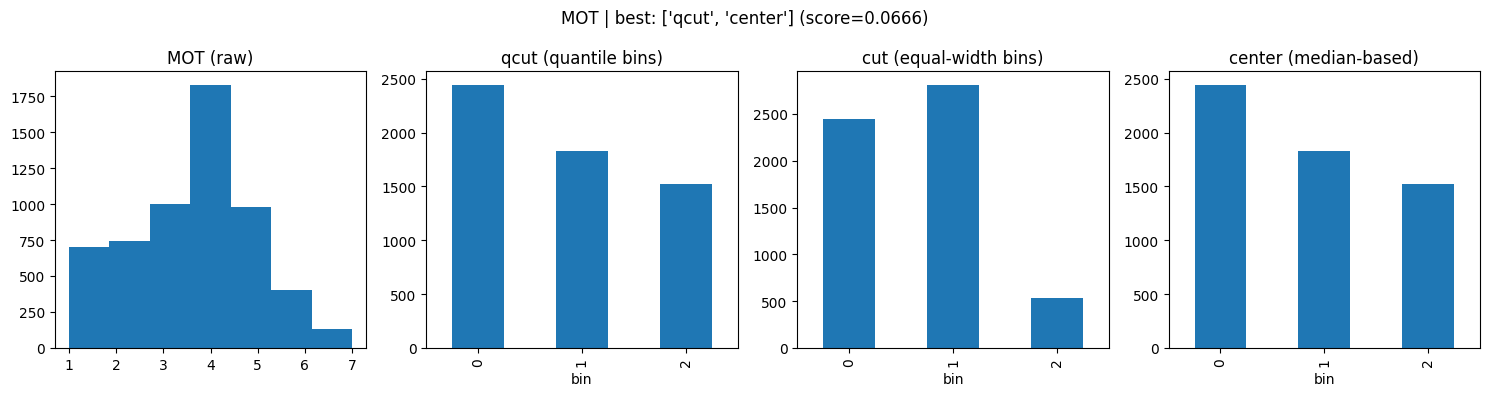

In [13]:
num_bins = 3
def balance_score(series):
    counts = series.value_counts(normalize=True)
    return np.std(counts.values)

for feature in possible_state_features:
    fig, axes = plt.subplots(1, 4, figsize=(15, 4))
    scores = {}

    # raw distribution (reference)
    axes[0].hist(samples[feature].dropna(), bins=7)
    axes[0].set_title(f"{feature} (raw)")

    # qcut
    binned_qcut = pd.qcut(samples[feature], q=num_bins, labels=False, duplicates='drop')
    binned_qcut.value_counts().sort_index().plot(kind='bar', ax=axes[1])
    axes[1].set_title("qcut (quantile bins)")
    axes[1].set_xlabel("bin")
    scores["qcut"] = balance_score(binned_qcut)

    # cut
    binned_cut = pd.cut(samples[feature], bins=num_bins, labels=False)
    binned_cut.value_counts().sort_index().plot(kind='bar', ax=axes[2])
    axes[2].set_title("cut (equal-width bins)")
    axes[2].set_xlabel("bin")
    scores["cut"] = balance_score(binned_cut)

    # binned around median
    binned_center = dp.bin_around_center(samples, feature) 
    pd.Series(binned_center).value_counts().sort_index().plot(kind='bar', ax=axes[3])
    axes[3].set_title("center (median-based)")
    axes[3].set_xlabel("bin")
    scores["center"] = balance_score(pd.Series(binned_center))

    min_score = min(scores.values())
    best_methods = [k for k, v in scores.items() if v == min_score]

    plt.suptitle(f"{feature} | best: {best_methods} (score={min_score:.4f})")
    plt.tight_layout()
    plt.show()

In [14]:
# We want to test multiple weight combinations
weights_list = np.random.dirichlet(np.ones(len(reward_cols)), size=1000)  

In [15]:
fixed_features = ['TIR', 'TIME_Q']
cluster_sizes = [2, 3, 4]
for cluster_size in cluster_sizes:
    print(f"Testing with cluster size: {cluster_size}")
    actions_clustered, _, cluster_cols = dp.cluster_actions(action_data, cluster_vars, num_clusters=cluster_size)
    num_actions = cluster_size * 2

    num_vals_per_feature = [2, 2, 2]
    print(f"     Testing with num_vals_per_feature: {num_vals_per_feature}")
    selected_with_fixed_multiple_weights = fs.feature_selection_with_fixed_multiple_weights(samples, actions_clustered, possible_state_features, fixed_features,
                                                        reward_cols, cluster_col, action_col, weights_list=weights_list, num_act=num_actions, num_vals_per_selected_feature=num_vals_per_feature,
                                                        discount_factor=0.7, scalarization='linear', max_count=max_count)
    
    num_vals_per_feature = [3, 3, 3]
    print(f"     Testing with num_vals_per_feature: {num_vals_per_feature}")
    selected_with_fixed_multiple_weights = fs.feature_selection_with_fixed_multiple_weights(samples, actions_clustered, possible_state_features, fixed_features,
                                                            reward_cols, cluster_col, action_col, weights_list=weights_list, num_act=num_actions, num_vals_per_selected_feature=num_vals_per_feature,
                                                            discount_factor=0.7, scalarization='linear', max_count=max_count)
    print()

Testing with cluster size: 2
     Testing with num_vals_per_feature: [2, 2, 2]
Candidate avg p-values: [np.float64(0.10293825942835387), np.float64(0.09587615715864901)]
Candidate avg F-stats: [np.float64(21.50789047487462), np.float64(19.408154042031434)]
Added: MOT (Avg p-value: 0.09587615715864901)
     Testing with num_vals_per_feature: [3, 3, 3]
Candidate avg p-values: [np.float64(0.046315219956451256), np.float64(0.04788247234885794)]
Candidate avg F-stats: [np.float64(39.828067193413176), np.float64(28.967883547793935)]
Added: GOOD (Avg p-value: 0.046315219956451256)

Testing with cluster size: 3
     Testing with num_vals_per_feature: [2, 2, 2]
Candidate avg p-values: [np.float64(0.060814332236438576), np.float64(0.060694480401647925)]
Candidate avg F-stats: [np.float64(34.56409762523959), np.float64(27.36795236579435)]
Added: MOT (Avg p-value: 0.060694480401647925)
     Testing with num_vals_per_feature: [3, 3, 3]
Candidate avg p-values: [np.float64(0.02741920497332885), np.fl

In [16]:
cluster_sizes = [2, 3, 4]
for cluster_size in cluster_sizes:
    print(f"Testing with cluster size: {cluster_size}")
    actions_clustered, _, cluster_cols = dp.cluster_actions(action_data, cluster_vars, num_clusters=cluster_size)
    num_actions = cluster_size * 2
    binning_combinations = [[2,2,2], [2,2,3], [2, 3, 2], [2, 3, 3], [3, 2, 2], [3, 2, 3], [3, 3, 2], [3, 3, 3]]

    results = fs.bin_selection_manual_combinations(
        df=samples,
        actions_clustered=actions_clustered,
        selected_features=['TIR', 'TIME_Q', 'MOT'],
        reward_cols=reward_cols,
        cluster_col=cluster_col,
        action_col=action_col,
        num_act=num_actions,
        binning_combinations=binning_combinations,  # or binning_combinations_dict
        weights_list=weights_list,
        max_count=max_count,
        discount_factor=0.7,
        scalarization='linear',
        seed=42,
        min_samples_per_state=10
    )
    print()

Testing with cluster size: 2
Testing 8 binning combinations
Features (in order): ['TIR', 'TIME_Q', 'MOT']
Using 1000 weight vectors


COMBINATION 1/8
Configuration: {'TIR': 2, 'TIME_Q': 2, 'MOT': 2}
State space size: 8
Coverage: 100.00% (8/8 states)
Samples per state: 433.9
Min samples per (s,a) pair: 14

Results:
  Mean p-value: 0.30 Â± 0.19
  Mean return: 1.9128 Â± 0.6373
P-values by feature:
  TIR: 0.54 Â± 0.19
  TIME_Q: 0.25 Â± 0.24
  MOT: 0.10 Â± 0.18

COMBINATION 2/8
Configuration: {'TIR': 2, 'TIME_Q': 2, 'MOT': 3}
State space size: 12
Coverage: 100.00% (12/12 states)
Samples per state: 289.2
Min samples per (s,a) pair: 12

Results:
  Mean p-value: 0.26 Â± 0.20
  Mean return: 1.9265 Â± 0.6163
P-values by feature:
  TIR: 0.43 Â± 0.21
  TIME_Q: 0.27 Â± 0.22
  MOT: 0.09 Â± 0.19

COMBINATION 3/8
Configuration: {'TIR': 2, 'TIME_Q': 3, 'MOT': 2}
State space size: 12
Coverage: 100.00% (12/12 states)
Samples per state: 289.2
Min samples per (s,a) pair: 5

Results:
  Mean p-value: 0.32 Â±

KeyboardInterrupt: 

In [18]:
cluster_sizes = [3, 4]
for cluster_size in cluster_sizes:
    print(f"Testing with cluster size: {cluster_size}")
    actions_clustered, _, cluster_cols = dp.cluster_actions(action_data, cluster_vars, num_clusters=cluster_size)
    num_actions = cluster_size * 2
    binning_combinations = [[2,2,2], [2,2,3], [2, 3, 2], [2, 3, 3], [3, 2, 2], [3, 2, 3], [3, 3, 2], [3, 3, 3]]

    results = fs.bin_selection_manual_combinations(
        df=samples,
        actions_clustered=actions_clustered,
        selected_features=['TIR', 'TIME_Q', 'GOOD'],
        reward_cols=reward_cols,
        cluster_col=cluster_col,
        action_col=action_col,
        num_act=num_actions,
        binning_combinations=binning_combinations,  # or binning_combinations_dict
        weights_list=weights_list,
        max_count=max_count,
        discount_factor=0.7,
        scalarization='linear',
        seed=42,
        min_samples_per_state=10
    )
    print()

Testing with cluster size: 3
Testing 8 binning combinations
Features (in order): ['TIR', 'TIME_Q', 'GOOD']
Using 1000 weight vectors


COMBINATION 1/8
Configuration: {'TIR': 2, 'TIME_Q': 2, 'GOOD': 2}
State space size: 8
Coverage: 100.00% (8/8 states)
Samples per state: 433.9
Min samples per (s,a) pair: 9

Results:
  Mean p-value: 0.32 Â± 0.15
  Mean return: 1.9387 Â± 0.6414
P-values by feature:
  TIR: 0.73 Â± 0.15
  TIME_Q: 0.17 Â± 0.21
  GOOD: 0.06 Â± 0.14

COMBINATION 2/8
Configuration: {'TIR': 2, 'TIME_Q': 2, 'GOOD': 3}
State space size: 12
Coverage: 100.00% (12/12 states)
Samples per state: 289.2
Min samples per (s,a) pair: 2

Results:
  Mean p-value: 0.39 Â± 0.13
  Mean return: 1.9396 Â± 0.6409
P-values by feature:
  TIR: 0.86 Â± 0.09
  TIME_Q: 0.27 Â± 0.21
  GOOD: 0.05 Â± 0.14

COMBINATION 3/8
Configuration: {'TIR': 2, 'TIME_Q': 3, 'GOOD': 2}
State space size: 12
Coverage: 100.00% (12/12 states)
Samples per state: 289.2
Min samples per (s,a) pair: 9

Results:
  Mean p-value: 0.3